In [1]:
import logging
from functools import partial

import astropy.constants as C
import cv2
import matplotlib.colors as colors
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from scipy.optimize import curve_fit
from tqdm import trange

logging.basicConfig(
    format="%(levelname)s: %(asctime)s: %(module)s %(funcName)s: %(message)s"
)
logging.getLogger().setLevel(logging.INFO)

import WindCube

# %matplotlib widget

plt.set_loglevel("warning")
rng = np.random.default_rng()

%load_ext autoreload
%autoreload 2

INFO: 2026-02-04 18:09:51,351: WindCube <module>: FOV is 2.35 square deg


# Instrument Parameters

In [2]:
deltavd = 2.5  # Etalon separation velocity error
deltavs = 1.0  # spacecraft velocity error
deltav0 = 1.0  # zero-point velocity error

deltavw = 5.0  # goal wind speed error

photon_flux = WindCube.transmission * np.load("photon_flux.npy")
calibration_flux = 10.0  # guess for now

# Calculate a Fringe pattern, the derivative wrt Doppler velocity, and an image

Text(0, 0.5, 'Y Pixel')

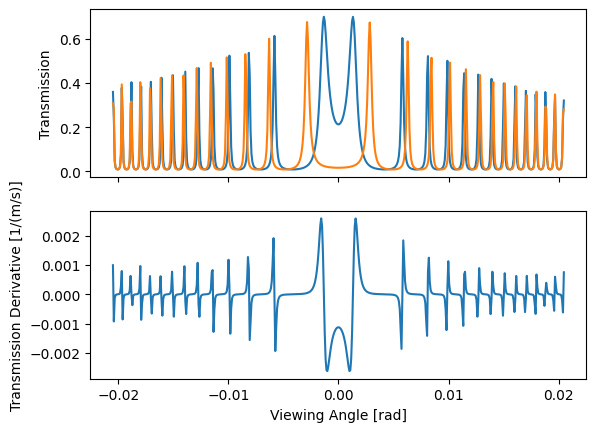

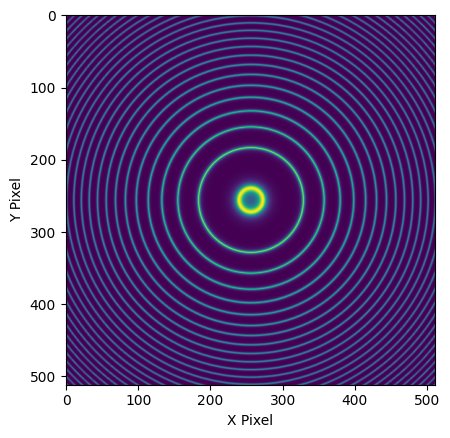

In [3]:
r = np.tile(np.linspace(-1, 1, num=WindCube.pixels) ** 2, (WindCube.pixels, 1))
rr = np.sqrt(r + np.transpose(r))
unique_r, unique_r_index = np.unique(rr, return_inverse=True)
a = WindCube.Atilde(
    unique_r,
    WindCube.calibration_wavelengths[0],
    WindCube.separation,
    WindCube.reflectivity,
)[unique_r_index]

fig, ax = plt.subplots(nrows=2, sharex=True)
r = np.linspace(-1, 1, num=WindCube.pixels)
ax[0].plot(
    WindCube.theta(r),
    WindCube.Atilde(
        r,
        WindCube.calibration_wavelengths[0],
        WindCube.separation,
        WindCube.reflectivity,
    ),
)
ax[0].plot(
    WindCube.theta(r),
    WindCube.Atilde(
        r,
        WindCube.line_wavelength,
        WindCube.separation,
        WindCube.reflectivity,
    ),
)
ax[0].set_ylabel("Transmission")
ax[1].plot(
    WindCube.theta(r),
    (
        WindCube.Atilde(
            r,
            WindCube.calibration_wavelengths[0],
            WindCube.separation,
            WindCube.reflectivity,
        )
        - WindCube.Atilde(
            r,
            WindCube.calibration_wavelengths[0] * (1 + 0.01 / C.c.value),
            WindCube.separation,
            WindCube.reflectivity,
        )
    )
    / 0.01,
)
ax[1].set_ylabel("Transmission Derivative [1/(m/s)]")
ax[1].set_xlabel("Viewing Angle [rad]")

fig, ax = plt.subplots()
ax.imshow(a)
ax.set_xlabel("X Pixel")
ax.set_ylabel("Y Pixel")

# Calculate a synthetic signal and its derivative wrt to velocity

In [4]:
dv = 0.1
a1 = WindCube.S(
    unique_r, 0.0, 1000.0, 0, 0, 1, WindCube.separation, WindCube.reflectivity
)[unique_r_index]
a2 = WindCube.S(
    unique_r, dv, 1000.0, 0, 0, 1, WindCube.separation, WindCube.reflectivity
)[unique_r_index]
dadv = (a2 - a1) / dv

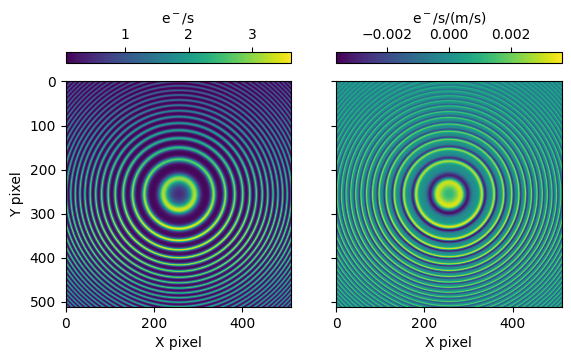

In [5]:
fig, ax = plt.subplots(ncols=2, sharey=True)
fig.colorbar(ax[0].imshow(a1 * photon_flux), location="top", label="e$^-$/s")
fig.colorbar(
    ax[1].imshow(dadv * photon_flux),
    location="top",
    label="e$^-$/s/(m/s)",
    norm=colors.CenteredNorm,
)
ax[0].set_xlabel("X pixel")
ax[1].set_xlabel("X pixel")
ax[0].set_ylabel("Y pixel")

fig.savefig("synthetic_signal.pdf", bbox_inches="tight")

# Calculate the required SNR to observe a 5 m/s wind speed

In [6]:
deltav = np.sqrt(deltavw**2 - deltavd**2 - deltavs**2 - deltav0**2)
print(f"Required Δv: {deltav:.2f} m/s")
deltaSS = np.sum(np.abs(dadv * photon_flux))
SS = np.sum(a1 * photon_flux)
print(f"SNR to delta-v ratio: {SS / deltaSS:.0f}")
required_SNR = SS / deltaSS / deltav
print(
    f"SNR required to measure wind speed with {deltavw} m/s precision: {required_SNR:.0f}"
)

Required Δv: 4.09 m/s
SNR to delta-v ratio: 908
SNR required to measure wind speed with 5.0 m/s precision: 222


# Calculate synthetic observations assuming a 10 s integration time

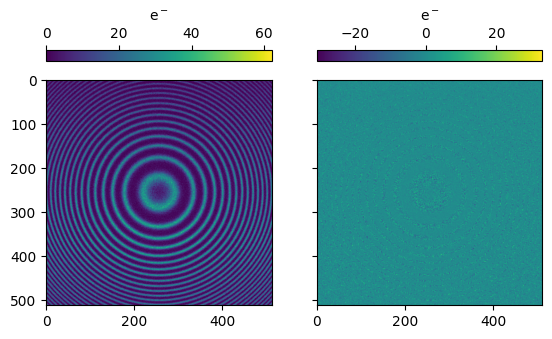

In [7]:
a3 = WindCube.S(
    unique_r,
    deltav,
    1000.0,
    0,
    0,
    1,
    WindCube.separation,
    WindCube.reflectivity,
)[unique_r_index]

s1 = rng.poisson(lam=a1 * photon_flux * 10)
s3 = rng.poisson(lam=a3 * photon_flux * 10)

fig, ax = plt.subplots(ncols=2, sharey=True)
fig.colorbar(ax[0].imshow(s1), location="top", label="e$^-$")
fig.colorbar(ax[1].imshow(s1 - s3), location="top", label="e$^-$")

# Calculate SNR as a function of exposure time and sensor temperature

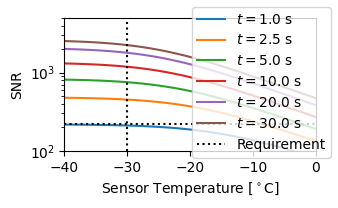

In [8]:
temperatures = np.linspace(230, 275)
Ctemperatures = temperatures - 273.15
exposures = np.array([1, 2.5, 5.0, 10, 20, 30])

dark = WindCube.darkcurrent(temperatures) * WindCube.pixels**2

fig, ax = plt.subplots(figsize=(3.4, 2.1))
ax.set_yscale("log")

for thisexposure in exposures:
    snr = (
        SS
        * thisexposure
        / np.sqrt(
            (SS + dark) * thisexposure
            + WindCube.read_noise * WindCube.pixels**2
        )
    )
    line = ax.plot(Ctemperatures, snr, label=f"$t = {thisexposure}$ s")

ax.axhline(required_SNR, c="k", ls=":", label="Requirement")
ax.axvline(WindCube.FPA_temperature - 273.15, c="k", ls=":")

ax.set_xlim(-40, 0)
ax.set_ylim(1e2, 5e3)

ax.set_xlabel(r"Sensor Temperature [$^\circ$C]")
ax.set_ylabel("SNR")
fig.legend(loc="upper right", ncols=1)

fig.tight_layout()

fig.savefig("SNR_vs_Tt.pdf")

In [9]:
thisexposure = 10
dark = WindCube.darkcurrent(243.15)
snr = (
    SS
    * thisexposure
    / np.sqrt(
        (SS + dark) * thisexposure + WindCube.read_noise * WindCube.pixels**2
    )
)
print(f"Nominal expected SNR for {thisexposure} s exposure: {snr:.0f}")
print(
    f"Nominal expected measurement error for {thisexposure} s exposure: {SS / deltaSS / snr:.2f} m/2"
)

Nominal expected SNR for 10 s exposure: 1342
Nominal expected measurement error for 10 s exposure: 0.68 m/2


# Create some synthetic observations for various exposure times and sensor temperatures

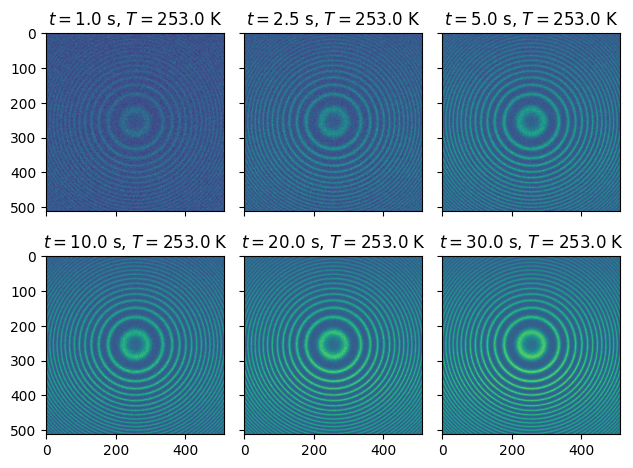

In [10]:
fig, ax = plt.subplots(ncols=3, nrows=2, sharex=True, sharey=True)
thistemperature = 253.0
for i, thisexposure in enumerate(exposures):
    s1 = rng.poisson(
        lam=(a3 * photon_flux + WindCube.darkcurrent(253)) * thisexposure
    ) + rng.poisson(lam=WindCube.read_noise * np.ones_like(a3))
    ax[i // 3, i % 3].imshow(s1, vmin=0)
    ax[i // 3, i % 3].set_title(
        f"$t = {thisexposure}$ s, $T = {thistemperature}$ K"
    )

fig.tight_layout()

fig.savefig("Simulated_Observations.pdf")

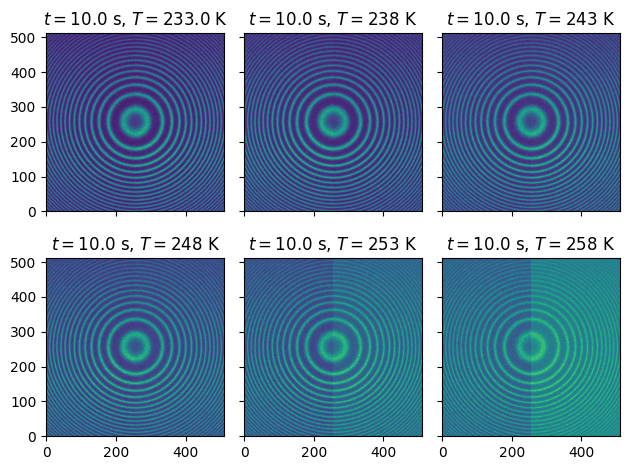

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=2, sharex=True, sharey=True)
temperatures = [233.0, 238, 243, 248, 253, 258]
thisexposure = 10.0
for i, thistemperature in enumerate(temperatures):
    s1 = rng.poisson(
        lam=(a3 * photon_flux + WindCube.darkcurrent(thistemperature))
        * thisexposure
    ) + rng.poisson(lam=WindCube.read_noise * np.ones_like(a3))
    ax[i // 3, i % 3].set_xlim(0, 511)
    ax[i // 3, i % 3].set_ylim(0, 511)
    ax[i // 3, i % 3].imshow(s1[:, 0:256], extent=(-0.5, 255.5, -0.5, 511.5))
    ax[i // 3, i % 3].imshow(
        s1[:, 256:], extent=(255.5, 511.5, -0.5, 511.5), vmin=0
    )
    ax[i // 3, i % 3].set_title(
        f"$t = {thisexposure}$ s, $T = {thistemperature}$ K"
    )

fig.tight_layout()

# Plot dark current for several exposure times as a function of temperature and compare against read noise

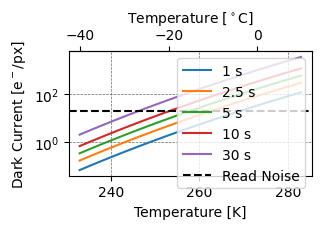

In [12]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
temp = np.linspace(233, 283)
ax.plot(temp, WindCube.darkcurrent(temp) * 1, label="1 s")
ax.plot(temp, WindCube.darkcurrent(temp) * 2.5, label="2.5 s")
ax.plot(temp, WindCube.darkcurrent(temp) * 5, label="5 s")
ax.plot(temp, WindCube.darkcurrent(temp) * 10, label="10 s")
ax.plot(temp, WindCube.darkcurrent(temp) * 30, label="30 s")
secax = ax.secondary_xaxis(
    "top", functions=(lambda t: t - 273.15, lambda t: t + 273.15)
)
secax.set_xlabel(r"Temperature [$^\circ$C]")
ax.set_xlabel(r"Temperature [K]")
ax.set_ylabel(r"Dark Current [e$^-$/px]")
ax.set_yscale("log")
ax.axhline(WindCube.read_noise**2, ls="--", c="k", label="Read Noise")
ax.grid(color="#666666", linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("dark_current.pdf")

# Observation Model

## Define system parameters

In [13]:
dx = 0.0  # pixels
dy = 0.0  # pixels
logging.info(f"Expected center position: ({255.5 - dx}, {255.5 - dy})")
v_spacecraft = 0.0  # m/s
v_dop = 0.0  # m/s
temperature = 500  # K

INFO: 2026-02-04 18:11:58,616: 1617036913 <module>: Expected center position: (255.5, 255.5)


## Recover Instrument Parameters from Calibration Data

Parameters to recover:
- FOV center point
- Etalon gap
- Etalon reflectivity
- Image blur parameters

Known parameters:
- Calibration wavelength
- Focal length

### Define calibration functions

In [14]:
def synth_cal_data(dx, dy):
    # synthesize a data set
    xgrid, ygrid = np.ogrid[0 : WindCube.pixels, 0 : WindCube.pixels]
    rcxcy = np.hypot(
        xgrid - (WindCube.pixels - 1) / 2 - dx,
        ygrid - (WindCube.pixels - 1) / 2 - dy,
    )
    unique_r, unique_r_index = np.unique(rcxcy, return_inverse=True)
    a = np.zeros((WindCube.pixels, WindCube.pixels))
    for calibration_wavelength, relative_intensity in zip(
        WindCube.calibration_wavelengths,
        WindCube.calibration_wavelengths_relative_intensity,
    ):
        a = (
            a
            + relative_intensity
            * WindCube.Atilde(
                unique_r / (WindCube.pixels - 1) * 2,
                calibration_wavelength,
                WindCube.separation,
                WindCube.reflectivity,
            )[unique_r_index]
        )

    return a


def observe_cal_data(a, exposure):
    s1 = (
        rng.poisson(
            lam=(
                a * calibration_flux
                + WindCube.darkcurrent(WindCube.FPA_temperature)
            )
            * exposure
        )
        + rng.poisson(lam=WindCube.read_noise * np.ones_like(a))
    ).astype(np.uint16)
    snr = np.sum(a * calibration_flux) / np.sqrt(np.sum(s1))
    logging.debug(f"Calibration SNR: {snr:.0f}")

    return s1


def analyze_cal_data(s1):
    # recover the FOV center and ring radii
    ret, edges = cv2.threshold(
        s1, 0, 65535, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # eliminate anything that touches the edge of the FOV
    edges[[0, -1], :] = 1  # make these 1 and then skip the first label below
    edges[:, [0, -1]] = 1

    # label the regions, region 1 contains the edge of the FOV and will be skipped
    num_labels, labels = cv2.connectedComponents(edges.astype(np.uint8))

    # loop over the regions and determine the center and radius
    cx, cy, n = 0, 0, 0
    diameters = np.zeros(num_labels - 2)
    for i, label in enumerate(np.arange(2, num_labels)):
        if (
            np.sum(labels == label) > 1000
        ):  # 1000 seems like a good cut-off based on some experiments
            (this_cy, this_cx), (major_axis, minor_axis), angle = (
                cv2.fitEllipse(
                    np.array(np.nonzero(labels == label)).transpose()
                )
            )
            cx += this_cx
            cy += this_cy
            n += 1
            diameters[i] = (major_axis + minor_axis) / 2 * WindCube.pixel_size
            logging.debug(
                f"Found fringe with diameter {diameters[i] * 1000:.4f} mm at ({this_cx:.4f}, {this_cy:.4f}) from {np.sum(labels == label)} points"
            )
    diameters = diameters[np.nonzero(diameters != 0)]

    cx, cy = cx / n, cy / n
    logging.info(f"Found center point ({cx:.4f}, {cy:.4f})")

    return cx, cy, diameters


def cal_fit_function(r, delta_d, delta_r, scale1, scale2, offset):
    a = np.zeros(r.size)
    for calibration_wavelength, scale in zip(
        WindCube.calibration_wavelengths, (scale1, scale2)
    ):
        a = a + scale * WindCube.Atilde(
            r,
            calibration_wavelength,
            WindCube.separation + delta_d * np.float64(1e-9),
            WindCube.reflectivity + delta_r * np.float64(1e-3),
        )
    return offset + a


def fit_cal_data(s1, cx, cy):
    r, mean, sem, stdev = WindCube.radial_mean(s1, cx, cy)
    rr = r / np.max(r) * np.sqrt(2)
    w = np.nonzero(rr <= 1.0)

    popt, pcov = curve_fit(
        cal_fit_function,
        rr[w],
        mean[w],
        p0=[rng.normal() / 10, 0.0, np.max(mean), np.max(mean), np.min(mean)],
        sigma=sem[w],
        absolute_sigma=True,
        ftol=1e-12,
    )

    model = cal_fit_function(rr, *popt)

    # scale fit parameters and errors
    popt[0] *= 1e-9
    popt[1] *= 1e-3
    perr = np.sqrt(np.diag(pcov))
    perr[0] *= 1e-9
    perr[1] *= 1e-3

    return popt, perr, r, mean, model

### Synthesize, observe, and analyze a calibration data set

INFO: 2026-02-04 18:12:11,562: 1492917558 analyze_cal_data: Found center point (255.5014, 255.4938)


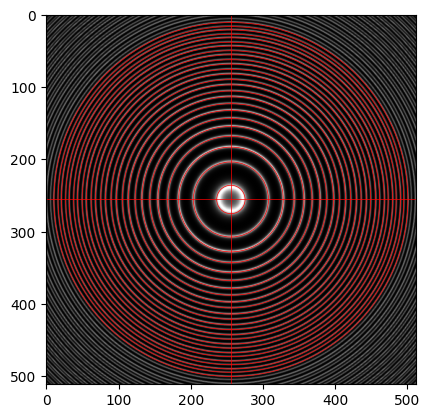

In [15]:
a = synth_cal_data(dx, dy)
s1 = observe_cal_data(a, 30.0)

# plot it
fig, ax = plt.subplots()
# ax.imshow(s1, cmap="gray")
ax.imshow(a, cmap="gray")

cx, cy, diameters = analyze_cal_data(s1)

for diameter in diameters:
    ax.add_patch(
        patches.Circle(
            (cx, cy),
            diameter / 2 / WindCube.pixel_size,
            fill=False,
            edgecolor="red",
            linewidth=0.5,
        )
    )
ax.axvline(cx, c="red", lw=0.5)
ax.axhline(cy, c="red", lw=0.5)

### Fit the data for the parameters

In [16]:
popt, perr, r, mean, model = fit_cal_data(s1, cx, cy)

print(f"Found etalon separation d = {WindCube.separation + popt[0]} m")
print(f"Found etalon reflectivity r = {WindCube.reflectivity + popt[1]} m")

Found etalon separation d = 0.020000000055905468 m
Found etalon reflectivity r = 0.8 m


/home/dfarrell/miniforge3/envs/sunpy/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/tmp/ipykernel_2484009/1492917558.py:104: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


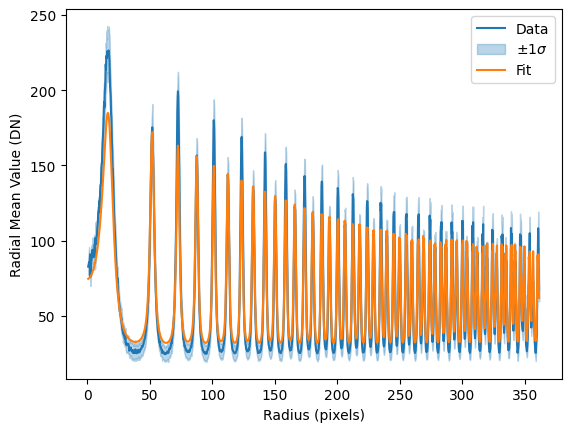

In [17]:
r, mean, sem, stdev = WindCube.radial_mean(s1, cx, cy)

fig, ax = plt.subplots()
ax.plot(r, mean, label="Data", color="C0")
ax.fill_between(
    r,
    mean - stdev,
    mean + stdev,
    color="C0",
    alpha=0.3,
    label=r"$\pm1\sigma$",
)
ax.plot(r, model, label="Fit", color="C1")
ax.set_xlabel("Radius (pixels)")
ax.set_ylabel("Radial Mean Value (DN)")
ax.legend()

fig.savefig("Calibration Radial Mean.pdf")

## Recover Wind Speed from Data

### Define science observation functions

In [18]:
def synth_sci_data(dx, dy, v_dop, temperature, v_spacecraft):
    # synthesize a data set
    data_rx = np.linspace(-1, 1, num=WindCube.pixels) + dx * 2 / WindCube.pixels
    data_ry = np.linspace(-1, 1, num=WindCube.pixels) + dy * 2 / WindCube.pixels
    xx, yy = np.meshgrid(data_rx, data_ry)  # shape (pixels, pixels)
    rr = np.sqrt(xx**2 + yy**2)
    unique_r, unique_r_index = np.unique(rr, return_inverse=True)
    a = WindCube.S(
        unique_r,
        v_dop,
        temperature,
        v_spacecraft,
        0,
        1,
        WindCube.separation,
        WindCube.reflectivity,
    )[unique_r_index]

    return a


def observe_sci_data(a, exposure):
    s1 = rng.poisson(
        lam=(a * photon_flux + WindCube.darkcurrent(WindCube.FPA_temperature))
        * thisexposure
    ) + rng.poisson(lam=WindCube.read_noise * np.ones_like(a))

    return s1


def sci_fit_function_simple(r, v_dop, scale, offset, v_spacecraft, temperature):
    signal = WindCube.S(
        r,
        v_dop,
        temperature,
        v_spacecraft,
        0.0,
        1.0,
        WindCube.separation,
        WindCube.reflectivity,
    )
    return scale * signal + offset


def fit_sci_data_simple(r, radial_mean, sem, v_spacecraft, temperature):
    # initial guess [v_dop (km/s), temperature (K), scale, offset]
    p0 = [
        np.float64(rng.normal() * 10),
        np.float64(np.mean(photon_flux) * thisexposure),
        np.float64(
            WindCube.darkcurrent(WindCube.FPA_temperature) * thisexposure
        ),
    ]
    logging.debug(f"Starting from {p0}")

    # absolute_sigma=True treats yerr as absolute 1-sigma errors -> covariance scaled appropriately
    popt, pcov, infodict, mesg, ier = curve_fit(
        partial(
            sci_fit_function_simple,
            v_spacecraft=v_spacecraft,
            temperature=temperature,
        ),
        r,
        radial_mean,
        p0=p0,
        sigma=sem,
        absolute_sigma=True,
        maxfev=20000,
        full_output=True,
        ftol=1e-12,
    )

    perr = np.sqrt(np.diag(pcov))
    logging.debug(f"Found {popt} ± {perr}, message: {mesg}")

    return popt, perr, ier


def analyze_sci_data(s1, v_spacecraft, cx, cy, temperature):
    r, s1_mean, s1_sem, s1_stdev = WindCube.radial_mean(s1, cx, cy)
    rr = r / np.max(r) * np.sqrt(2)
    w = np.nonzero(rr <= 0.5)

    (v_dop, scale, offset), (v_dop_err, scale_err, offset_err), ier = (
        fit_sci_data_simple(
            rr[w], s1_mean[w], s1_sem[w], v_spacecraft, temperature
        )
    )

    return v_dop, ier


def plot_sci_data_analysis(
    r, s1_mean, s1_sem, v_dop, scale, offset, v_spacecraft, temperature
):
    rr = r / np.max(r) * np.sqrt(2)
    fig, ax = plt.subplots()
    ax.plot(r, s1_mean, label="Data", color="C0")
    ax.fill_between(
        r,
        s1_mean - s1_sem,
        s1_mean + s1_sem,
        color="C0",
        alpha=0.3,
        label="±1 SEM",
    )
    ax.plot(
        r,
        sci_fit_function_simple(
            rr, v_dop, scale, offset, v_spacecraft, temperature
        ),
        color="C1",
        label="Fit",
    )
    ax.legend()

In [19]:
# synthesize a data set
dx = 0.0
dy = 0.0
cx = 255.5
cy = 255.5
v_dop = 0.0
temperature = 500.0
v_spacecraft = 0.0
a = synth_sci_data(dx, dy, v_dop, temperature, v_spacecraft)

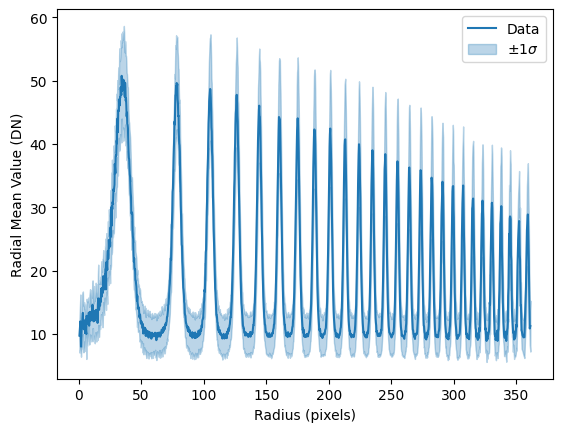

In [20]:
s1 = observe_sci_data(a, 10.)
r, mean, sem, stdev = WindCube.radial_mean(s1, cx, cy)

fig, ax = plt.subplots()
ax.plot(r, mean, label="Data", color="C0")
ax.fill_between(
    r,
    mean - stdev,
    mean + stdev,
    color="C0",
    alpha=0.3,
    label=r"$\pm1\sigma$",
)
ax.set_xlabel("Radius (pixels)")
ax.set_ylabel("Radial Mean Value (DN)")
ax.legend()

In [21]:
samples = 1000
thisexposure = 10  # s


def wrapper(a, i):
    try:
        thisvdop, ier = analyze_sci_data(
            observe_sci_data(a, thisexposure), v_spacecraft, cx, cy, temperature
        )
        logging.debug(f"Finished sample {i}, found v_dop = {thisvdop}.")
    except Exception as e:
        logging.warning(f"Something went wrong with sample {i}.")
        thisvdop = float("nan")
    return thisvdop, ier


logging.getLogger().setLevel(logging.INFO)
vdops = np.array(list([wrapper(a, i) for i in range(samples)]))

/tmp/ipykernel_2484009/2137605137.py:57: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov, infodict, mesg, ier = curve_fit(
/home/dfarrell/miniforge3/envs/sunpy/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma


Found Delta v_dop = -1.66 ± 1.90 m/s


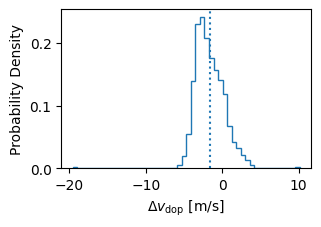

In [22]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
histogram, edges = np.histogram(vdops[:, 0], bins=50, density=True)
ax.stairs(histogram, edges, color="C0")
ax.axvline(np.mean(vdops[:,0]), ls=":", color="C0")
ax.set_xlabel(r"$\Delta v_\mathrm{dop}$ [m/s]")
ax.set_ylabel(r"Probability Density")
fig.tight_layout()
fig.savefig("PDF.pdf")
print(f"Found Delta v_dop = {np.mean(vdops[:,0]):.2f} ± {np.std(vdops[:,0]):.2f} m/s")

eventually want this notebook to: 
- generate calibration and science data 
- analyze them (the fitting routines are slightly different) 
- recover params we set 

important to note: hard to recover some params (like temp) because small errors can add up and data is noisy 
really only care about wind velocity so we just need to recover that correctly  